In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import pickle, utils
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import bartlett, sem
from PIL import Image

In [2]:
def to_day(di):
    if di >= 2:
        return "Day6"
    else:
        return "Day" + str(di + 1)

In [3]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)

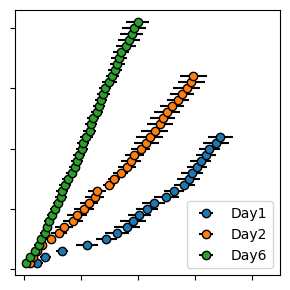

In [4]:
plt.figure(figsize=(3, 3))
for di in range(3):
    tmp = np.zeros((100, 6))
    tmp[:, :] = np.nan
    for mi in range(6):
        rew = np.where(beh[mi][di][:, 2])[0]
        tmp[:len(rew), mi] = rew
    n = np.sum(np.isnan(tmp).sum(axis=1) == 0)
    xerr = stats.sem(tmp[:n], axis=1)
    plt.errorbar(tmp[:n].mean(axis=1), np.arange(1, n+1), xerr=xerr, fmt="o", ecolor="black", markeredgecolor="black", color="C"+str(di), label=to_day(di))
plt.legend()
plt.xticks([5000*i for i in range(5)], [1000*i for i in range(5)])
plt.xlim(plt.xlim()[0], 4.5*5000)
plt.yticks([10*i for i in range(5)])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig2/fig2c.png")

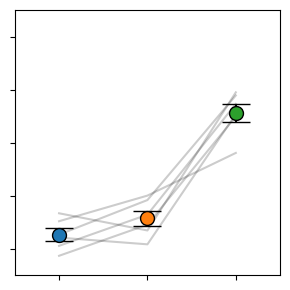

In [5]:
tmp = np.zeros((6, 3))
plt.figure(figsize=(3, 3))
for mi in range(6):
    for di in range(3):
        tmp[mi, di] = beh[mi][di][:, 2].sum() / beh[mi][di][:, 1].sum()
plt.plot(tmp.T, color="black", alpha=0.2, zorder=1)
for di in range(3):
    plt.errorbar(di, tmp[:, di].mean(), fmt="o", yerr=stats.sem(tmp[:, di]), ecolor="black", markeredgecolor="black", color="C"+str(di), markersize=10, capsize=10)
plt.xticks(np.arange(3))
plt.xlim(-0.5, 2.5)
plt.yticks(np.arange(1, 6) * 0.2)
plt.ylim(0.1, 1.1)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/fig2/fig2d.png")

In [6]:
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "rate": tmp.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6),
})
print(AnovaRM(data=df, depvar="rate", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df['rate'],
                          groups=df['day'],
                          alpha=0.05)
print(tukey)

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day 65.7029 2.0000 10.0000 0.0000

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   0.0619 0.3172 -0.0451  0.169  False
  Day1   Day6   0.4608    0.0  0.3538 0.5678   True
  Day2   Day6   0.3989    0.0  0.2919 0.5059   True
---------------------------------------------------


In [7]:
T = 100
params = np.zeros((6, 3, T, 2, 5))
dist = np.zeros((6, 3, T, 2))
for mi in range(6):
    for di in range(3):
        p, d = utils.cmp_traj(beh[mi][di][:, 5:], beh[mi][di][:, 1:3], T=T)
        params[mi, di, :, :, :] = p
        dist[mi, di, :, :] = d

In [8]:
def plot_movement(loc, mode, filename=None):
    sfi = 0 if mode == "succ" else 1
    ax = plt.subplot(111, projection="3d")
    mx = [0, 18, 32, 40, 28, 40, 32, 18, 0, 0]
    my = [26, 26, 40, 32, 20, 8, 0, 14, 14, 26]
    mx_zone = [18, 32, 40, 28, 18]
    my_zone = [26, 40, 32, 20, 26]
    ax.plot(mx, my, 0, color="k", zorder=0)
    ax.plot(mx, my, 20, color="k", zorder=3)
    for mi in range(6):
        for di in range(3):
            mu = loc[mi, di, :, sfi, :]
            ax.plot(mu[:, 0], mu[:, 1] if di < 2 else 40 - mu[:, 1], 20 - np.arange(100)/5, color="C"+str(di), zorder=1)
    for i in range(5):
        if i >= 1 and i < 4:
            verts = [list(zip(mx, my, np.ones_like(mx)*5*i))]
            ax.add_collection3d(Poly3DCollection(verts, facecolor="k", alpha=0.1, zorder=2))
        verts = [list(zip(mx_zone, my_zone, np.ones_like(mx_zone)*5*i))]
        ax.add_collection3d(Poly3DCollection(verts, facecolor="r", alpha=0.1, zorder=2))
    for i in range(4):
        for di in range(3):
            ax.scatter(loc[:, di, 25*i, sfi, 0], loc[:, di, 25*i, sfi, 1] if di < 2 else 40 - loc[:, di, 25*i, sfi, 1], 20 - np.ones(6)*5*i, color="C"+str(di), alpha=0.8, zorder=1)
    plt.axis("off")
    ax.view_init(elev=30, azim=-60)
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename)
    plt.show()
    return

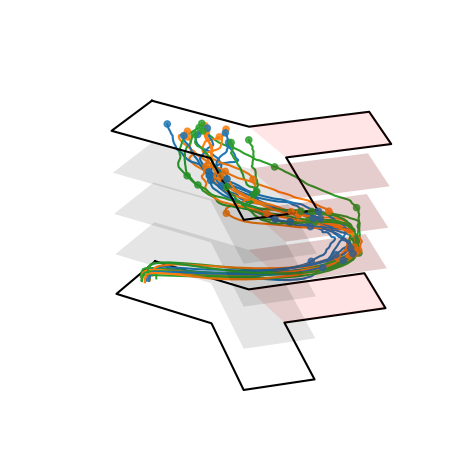

In [9]:
plot_movement(params[:, :, :, :, :2], "succ", "figures/fig2/fig2e.png")

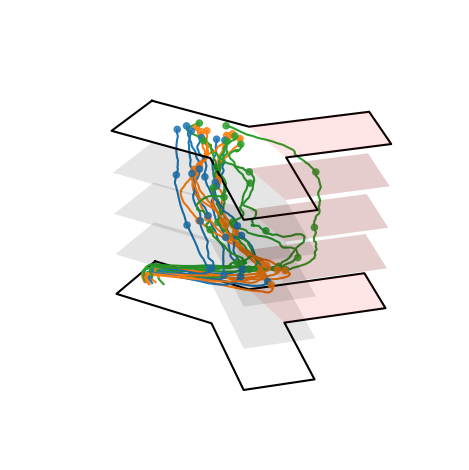

In [10]:
plot_movement(params[:, :, :, :, :2], "fail", "figures/fig2/fig2f.png")

In [11]:
for filename in ["figures/fig2/fig2e.png", "figures/fig2/fig2f.png"]:
    im = Image.open(filename)
    im.crop((197, 105, 476, 396)).save(filename)

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  1.4989 2.0000 10.0000 0.2696

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -1.3448 0.3046 -3.6248 0.9353  False
  Day1   Day6  -0.4919 0.8428  -2.772 1.7881  False
  Day2   Day6   0.8528 0.6052 -1.4272 3.1329  False
---------------------------------------------------


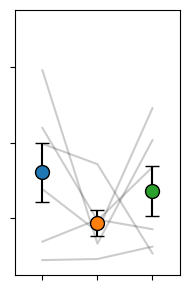

In [12]:
euc = dist[:, :, :, 0].mean(axis=-1)
plt.figure(figsize=(2, 3))
plt.plot(euc.T, color="k", alpha=0.2)
for di in range(3):
    plt.errorbar(x=di, y=euc[:, di].mean(), yerr=sem(euc[:, di]), fmt="o", ecolor="k", markeredgecolor="k", color="C"+str(di), capsize=5, markersize=10)
plt.xlim(-0.5, 2.5)
plt.ylim(6.5, 13.5)
plt.tick_params(labelbottom=False, labelleft=False)
plt.yticks([8, 10, 12])
plt.tight_layout()
plt.savefig("figures/fig2/fig2g.png")
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "dist": euc.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6)
})
print(AnovaRM(data=df, depvar="dist", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df['dist'], groups=df['day'], alpha=0.05)
print(tukey)

In [13]:
mahal = dist[:, :, :, 1].mean(axis=-1)
bartlett(mahal[:, 0], mahal[:, 1], mahal[:, 2])

BartlettResult(statistic=13.042364032600677, pvalue=0.0014719282305258369)

BartlettResult(statistic=1.2982344391429663, pvalue=0.5225068320308732)
              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day  2.2249 2.0000 10.0000 0.1587

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2  -0.5542 0.1325 -1.2535 0.1451  False
  Day1   Day6  -0.1068 0.9173 -0.8061 0.5925  False
  Day2   Day6   0.4474 0.2517 -0.2519 1.1467  False
---------------------------------------------------


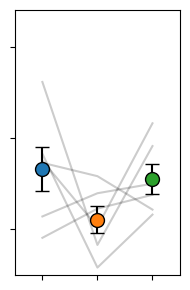

In [14]:
mahal = np.log(dist[:, :, :, 1]).mean(axis=-1)
print(bartlett(mahal[:, 0], mahal[:, 1], mahal[:, 2]))
plt.figure(figsize=(2, 3))
plt.plot(mahal.T, color="k", alpha=0.2)
for di in range(3):
    plt.errorbar(x=di, y=mahal[:, di].mean(), yerr=sem(mahal[:, di]), fmt="o", ecolor="k", markeredgecolor="k", color="C"+str(di), capsize=5, markersize=10)
plt.xlim(-0.5, 2.5)
plt.ylim(-1.5, 1.4)
plt.tick_params(labelbottom=False, labelleft=False)
plt.yticks([-1, 0, 1])
plt.tight_layout()
plt.savefig("figures/fig2/fig2h.png")
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 3),
    "dist": mahal.T.reshape(-1),
    "day": np.repeat([to_day(di) for di in range(3)], 6)
})
print(AnovaRM(data=df, depvar="dist", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df['dist'], groups=df['day'], alpha=0.05)
print(tukey)

In [15]:
with open("beh345.pkl", "rb") as f:
    beh345 = pickle.load(f)

In [16]:
licks = []
for mi in range(6):
    licks.append([
        beh[mi][0][:, 1:3], beh[mi][1][:, 1:3], beh345[mi][0][:, 1:3], 
        beh345[mi][1][:, 1:3], beh345[mi][2][:, 1:3], beh[mi][2][:, 1:3], 
    ])

In [17]:
colors = ["C0", "C1", "C3", "C4", "C5", "C2"]

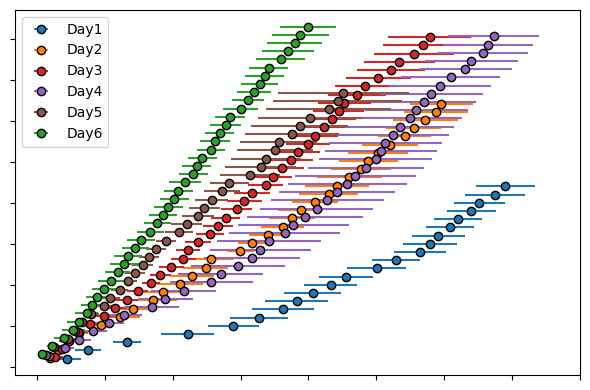

In [18]:
plt.figure(figsize=(6, 4))
for di in range(6):
    tmp = np.zeros((100, 6))
    tmp[:, :] = np.nan
    for mi in range(6):
        rew = np.where(licks[mi][di][:, 1])[0]
        tmp[:len(rew), mi] = rew
    n = np.sum(np.isnan(tmp).sum(axis=1) == 0)
    xerr = stats.sem(tmp[:n], axis=1)
    plt.errorbar(tmp[:n].mean(axis=1), np.arange(1, n+1)+0.1*di, xerr=xerr, fmt="o", ecolor=colors[di], markeredgecolor="black", color=colors[di], label="Day" + str(di+1))
plt.legend()
plt.xticks([2500*i for i in range(9)], [500*i for i in range(9)])
plt.xlim(plt.xlim()[0], 4*5000)
plt.yticks([5*i for i in range(9)])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs4/figs4a.png")

              Anova
    F Value Num DF  Den DF Pr > F
---------------------------------
day 21.5095 5.0000 25.0000 0.0000

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  Day1   Day2   0.0619 0.8237 -0.0925 0.2164  False
  Day1   Day3    0.134 0.1188 -0.0204 0.2884  False
  Day1   Day4   0.1073 0.3077 -0.0471 0.2617  False
  Day1   Day5   0.3201    0.0  0.1656 0.4745   True
  Day1   Day6   0.4608    0.0  0.3064 0.6152   True
  Day2   Day3    0.072 0.7156 -0.0824 0.2265  False
  Day2   Day4   0.0454 0.9451 -0.1091 0.1998  False
  Day2   Day5   0.2581 0.0002  0.1037 0.4126   True
  Day2   Day6   0.3989    0.0  0.2444 0.5533   True
  Day3   Day4  -0.0267 0.9947 -0.1811 0.1278  False
  Day3   Day5   0.1861 0.0111  0.0316 0.3405   True
  Day3   Day6   0.3268    0.0  0.1724 0.4813   True
  Day4   Day5   0.2127 0.0028  0.0583 0.3672   True
  Day4   Day6   0.3535    0.0  0.1991 0.5079 

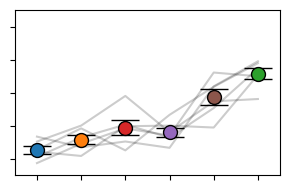

In [19]:
tmp = np.zeros((6, 6))
plt.figure(figsize=(3, 2))
for mi in range(6):
    for di in range(6):
        tmp[mi, di] = licks[mi][di][:, 1].sum() / licks[mi][di][:, 0].sum()
plt.plot(tmp.T, color="black", alpha=0.2, zorder=1)
for di in range(6):
    plt.errorbar(di, tmp[:, di].mean(), fmt="o", yerr=stats.sem(tmp[:, di]), ecolor="black", markeredgecolor="black", color=colors[di], markersize=10, capsize=10)
plt.xticks(np.arange(6))
plt.xlim(-0.5, 5.5)
plt.yticks(np.arange(1, 6) * 0.2)
plt.ylim(0.1, 1.1)
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs4/figs4b.png")
df = pd.DataFrame({
    "mouse": np.tile(np.arange(1, 7), 6),
    "rate": tmp.T.reshape(-1),
    "day": np.repeat(["Day" + str(di+1) for di in range(6)], 6)
})
print(AnovaRM(data=df, depvar="rate", subject="mouse", within=["day"]).fit())
tukey = pairwise_tukeyhsd(endog=df["rate"], groups=df["day"], alpha=0.05)
print(tukey)